In [1]:
import pandas as pd
from pathlib import Path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import math



In [2]:
respath = Path("../../results/synthetic/s123")
#respath = Path("/Users/jangorecki/PythonWork/bcause/papers/gradient_journal/results/synthetic/s123")    # TODO : set the local path here
filenames = glob.glob(f"{respath}/*.csv")
print(len(filenames))

filenames

2798


['../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_185_uai_EMCC_150_n200_roFalse_s0.csv',
 '../../results/synthetic/s123/random_mc2_n6_mid3_d1000_05_mr098_r10_116_uai_GDCC_1e-07_n200_roTrue_s0.csv',
 '../../results/synthetic/s123/random_mc2_n5_mid3_d1000_05_mr098_r10_190_uai_GDCC_1e-05_n200_roFalse_s0.csv',
 '../../results/synthetic/s123/random_mc2_n5_mid3_d1000_05_mr098_r10_89_uai_EMCC_50_n200_roFalse_s0.csv',
 '../../results/synthetic/s123/random_mc2_n6_mid3_d1000_05_mr098_r10_162_uai_EMCC_150_n200_roTrue_s0.csv',
 '../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_49_uai_EMCC_100_n200_roFalse_s0.csv',
 '../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_145_uai_GDCC_1e-09_n200_roFalse_s0.csv',
 '../../results/synthetic/s123/random_mc2_n6_mid3_d1000_05_mr098_r10_28_uai_GDCC_1e-07_n200_roTrue_s0.csv',
 '../../results/synthetic/s123/random_mc2_n7_mid3_d1000_05_mr098_r10_139_uai_GDCC_1e-09_n200_roTrue_s0.csv',
 '../../results/synthetic/

In [3]:
#data = pd.concat([pd.read_csv(respath.joinpath(f), index_col=0) for f in filenames], axis=0, ignore_index=True)
data = pd.concat([pd.read_csv(f, index_col=0) for f in filenames], axis=0, ignore_index=True)


In [4]:
data["time"]= data.tlearn + data.tinfer

In [5]:
data

,modelname,method,cause,effect,tol,num_runs_param,max_iter_param,seed,tlearn,tinfer,remove_outliers,datasize,pns_low_exact,pns_upp_exact,pns_low,pns_upp,rrmse,rmse,nruns,time
0,random_mc2_n7_mid3_d1000_05_mr098_r10_185,EMCC_150,V4,V5,NaN,200,150.0,0,23677.387238,108.629942,False,5000,0.026299,0.362919,0.231118,0.231118,inf,0.172224,1,23786.017179
1,random_mc2_n7_mid3_d1000_05_mr098_r10_185,EMCC_150,V4,V5,NaN,200,150.0,0,47295.146465,214.891434,False,5000,0.026299,0.362919,0.165298,0.231118,2.057858,0.135448,2,47510.037899
2,random_mc2_n7_mid3_d1000_05_mr098_r10_185,EMCC_150,V4,V5,NaN,200,150.0,0,71067.832232,322.151661,False,5000,0.026299,0.362919,0.165298,0.231118,2.057858,0.135448,3,71389.983892
3,random_mc2_n7_mid3_d1000_05_mr098_r10_185,EMCC_150,V4,V5,NaN,200,150.0,0,94931.279421,432.576656,False,5000,0.026299,0.362919,0.165298,0.256821,1.350990,0.123648,4,95363.856077
4,random_mc2_n7_mid3_d1000_05_mr098_r10_185,EMCC_150,V4,V5,NaN,200,150.0,0,118629.270792,537.439346,False,5000,0.026299,0.362919,0.165298,0.256821,1.350990,0.123648,5,119166.710138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559595,random_mc2_n8_mid3_d1000_05_mr098_r10_189,GDCC_1e-05,V4,V7,0.00001,200,NaN,0,310031.906128,15674.209833,True,1000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,196,325706.115961
559596,random_mc2_n8_mid3_d1000_05_mr098_r10_189,GDCC_1e-05,V4,V7,0.00001,200,NaN,0,312344.415426,15737.780809,True,1000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,197,328082.196236
559597,random_mc2_n8_mid3_d1000_05_mr098_r10_189,GDCC_1e-05,V4,V7,0.00001,200,NaN,0,314674.214363,15687.519550,True,1000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,198,330361.733913
559598,random_mc2_n8_mid3_d1000_05_mr098_r10_189,GDCC_1e-05,V4,V7,0.00001,200,NaN,0,316997.954845,15937.591791,True,1000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,199,332935.546637


In [6]:
data["iter"] = data["max_iter_param"]

# Select the relevant data
df = data[["nruns", "time",  'rmse', 'method', "remove_outliers", "iter", "tol"]]


df = df.drop(df[df.iter.isin([25, 200])].index)
df = df.drop(df[df.tol.isin([0.001])].index)
#df["method2"] = df.apply(lambda t : t["method"]+" "+[f"{c}={t[c]}" for c in ["iter", "tol"] if not math.isnan(t[c])][0] if t["method"]!="GSCC" else "GSCC", axis=1)

In [12]:
df["method"].unique()

array(['EMCC_150', 'GDCC_1e-07', 'GDCC_1e-05', 'EMCC_50', 'EMCC_100',
       'GDCC_1e-09', 'GSCC'], dtype=object)

In [22]:
methods = ['EMCC_150', 'GDCC_1e-07', 'GDCC_1e-05','GDCC_1e-09', 'GSCC']

df.method in methods

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

<AxesSubplot:xlabel='nruns', ylabel='time'>

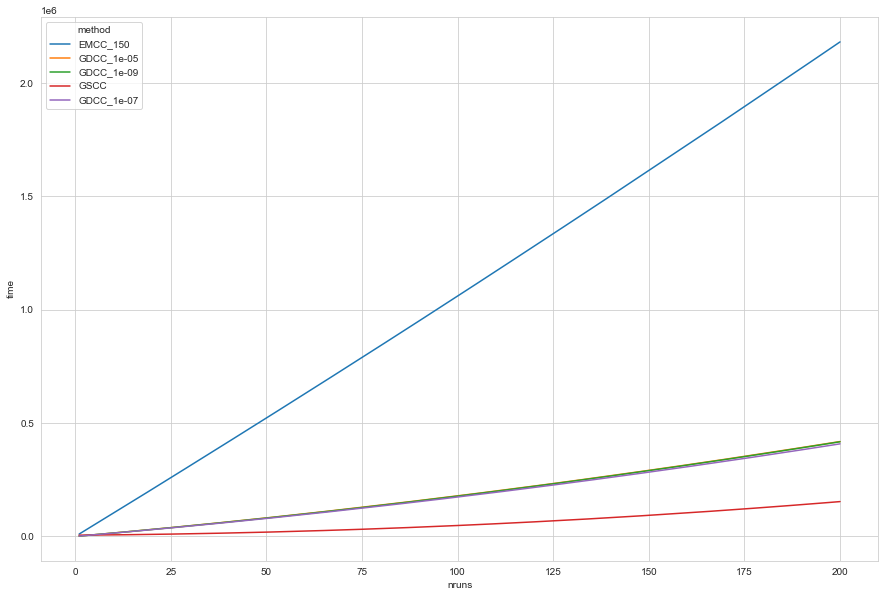

In [23]:
# Time with outliers removal
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[(df.remove_outliers==False) & (df.method.isin(methods))],
    x="nruns", y="time",
    hue="method",
    errorbar=None,
#    palette=custom_palette,
#    hue_order=hue_order
)

<AxesSubplot:xlabel='nruns', ylabel='rmse'>

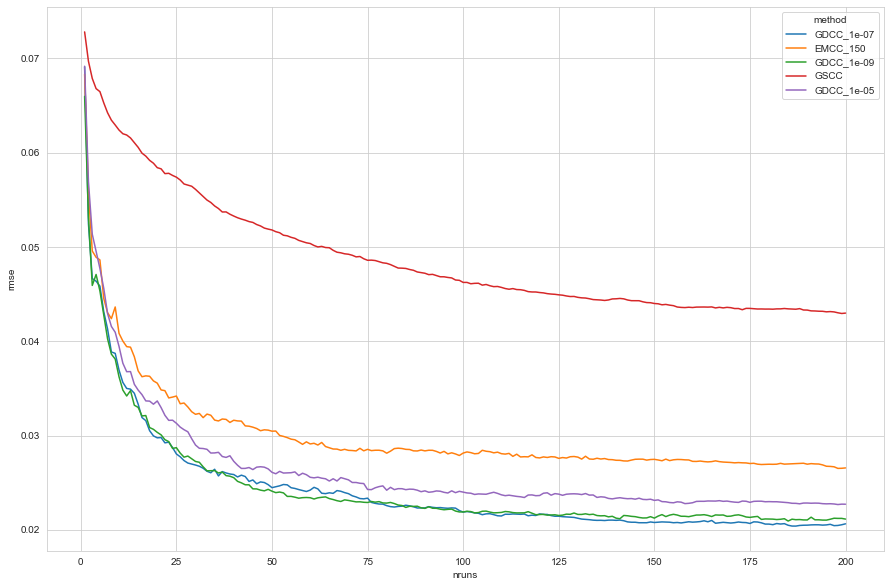

In [25]:
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[(df.remove_outliers==True) & (df.method.isin(methods))],
    x="nruns", y="rmse",
    hue="method",
    errorbar=None,
#    palette=custom_palette,
#    hue_order=hue_order
)

<AxesSubplot:xlabel='nruns', ylabel='time'>

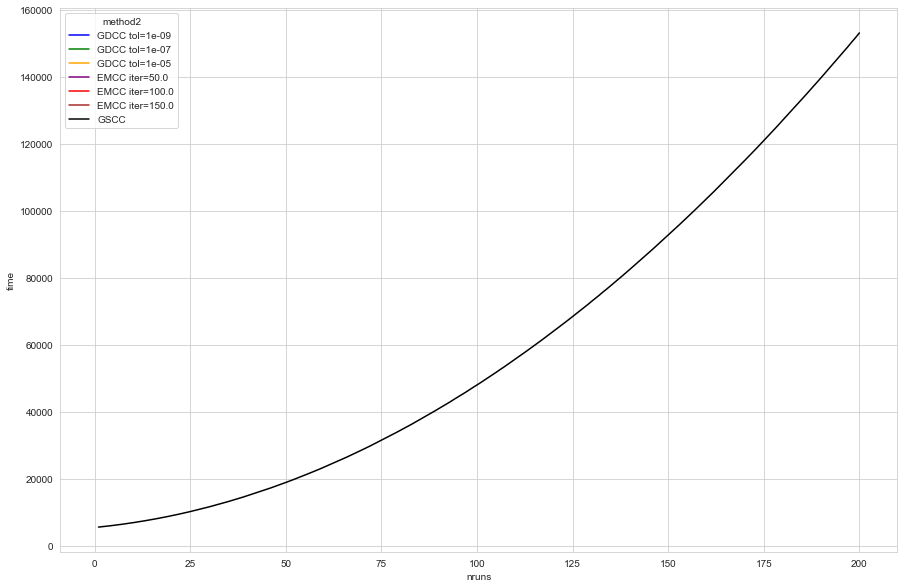

In [8]:
# Define custom colors for each method
custom_palette = {
    "GDCC tol=1e-09": "blue",
    "GDCC tol=1e-07": "green",
    "GDCC tol=1e-05": "orange",
    "EMCC iter=50.0": "purple",
    "EMCC iter=100.0": "red",
    "EMCC iter=150.0": "brown",
    "GSCC": "black"
}

# Define the order based on increasing values
hue_order = ["GDCC tol=1e-09", "GDCC tol=1e-07", "GDCC tol=1e-05", 
             "EMCC iter=50.0", "EMCC iter=100.0", "EMCC iter=150.0", "GSCC"]

# Time with outliers removal
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[df.remove_outliers==True], 
    x="nruns", y="time", 
    hue="method2", 
    errorbar=None, 
    palette=custom_palette, 
    hue_order=hue_order
)

<AxesSubplot:xlabel='nruns', ylabel='rmse'>

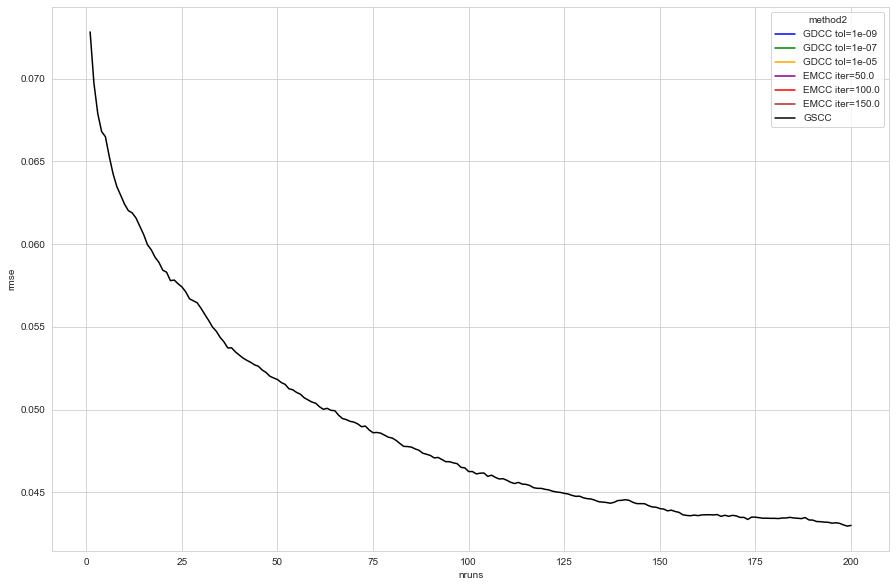

In [9]:
# Error with outliers removal
fig, ax = plt.subplots(figsize=(15, 10))
# Plot with custom colors and sorted legend
sns.lineplot(
    data=df.loc[df.remove_outliers==True], 
    x="nruns", y="rmse", 
    hue="method2", 
    errorbar=None, 
    palette=custom_palette, 
    hue_order=hue_order
)